# Radix tree structure & access statistics

Loads experiment JSON under `../results/json_<dataset>/`. Set env `KV_SIM_PLOT_DATASET` to match experiments `--dataset`. Each file contains `metrics.tree_depth_histogram` (node count per depth), `metrics.tree_access_by_depth` (aggregate access stats), and `metrics.access_percentiles_by_depth` (min / p50 / p90 / p99 / max of `access_count` per depth — requires re-running simulations after metrics update).

Only `capacity=inf` runs are plotted. X-axis is token position (`depth * page_size`) so different page sizes share the same scale.

In [ ]:
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ROOT = Path("..").resolve()
RES = ROOT / "results"
DATASET = os.environ.get("KV_SIM_PLOT_DATASET", "loogle")
DATASET = "narrativeqa"
# DATASET = "mooncake_toolagent"
DATASET = "swesmith"

ORDERING = "random"  # original | min_distance | max_distance | random

JSON_SUBDIR = f"json_{DATASET}"

In [2]:
def load_result_jsons(subdir: str = "page_size_json") -> list[dict]:
    d = RES / subdir
    if not d.is_dir():
        print(f"Missing {d}")
        return []
    out = []
    for p in sorted(d.glob("*.json")):
        with p.open(encoding="utf-8") as f:
            row = json.load(f)
        row["_path"] = p.name
        out.append(row)
    print(f"Loaded {len(out)} JSON files from {d}")
    return out

In [3]:
def depth_hist_to_series(h: dict) -> pd.Series:
    if not h:
        return pd.Series(dtype=float)
    idx = sorted(h.keys(), key=lambda x: int(x))
    return pd.Series({int(k): int(h[k]) for k in idx})


def access_agg_to_frame(acc: dict) -> pd.DataFrame:
    if not acc:
        return pd.DataFrame()
    rows = []
    for k in sorted(acc.keys(), key=lambda x: int(x)):
        r = {"depth": int(k), **acc[k]}
        rows.append(r)
    return pd.DataFrame(rows)


def percentiles_to_frame(pct: dict) -> pd.DataFrame:
    if not pct:
        return pd.DataFrame()
    rows = [{"depth": int(k), **v} for k, v in sorted(pct.items(), key=lambda kv: int(kv[0]))]
    return pd.DataFrame(rows)

## 1. Node count vs token position (tree shape)

One row per `page_size`. Color family = strategy, shade = capacity.

Loaded 72 JSON files from /data/howarli/dev/LLM-prefix-caching-simulator/results/json_swesmith
Loaded 36 runs (ordering=original)


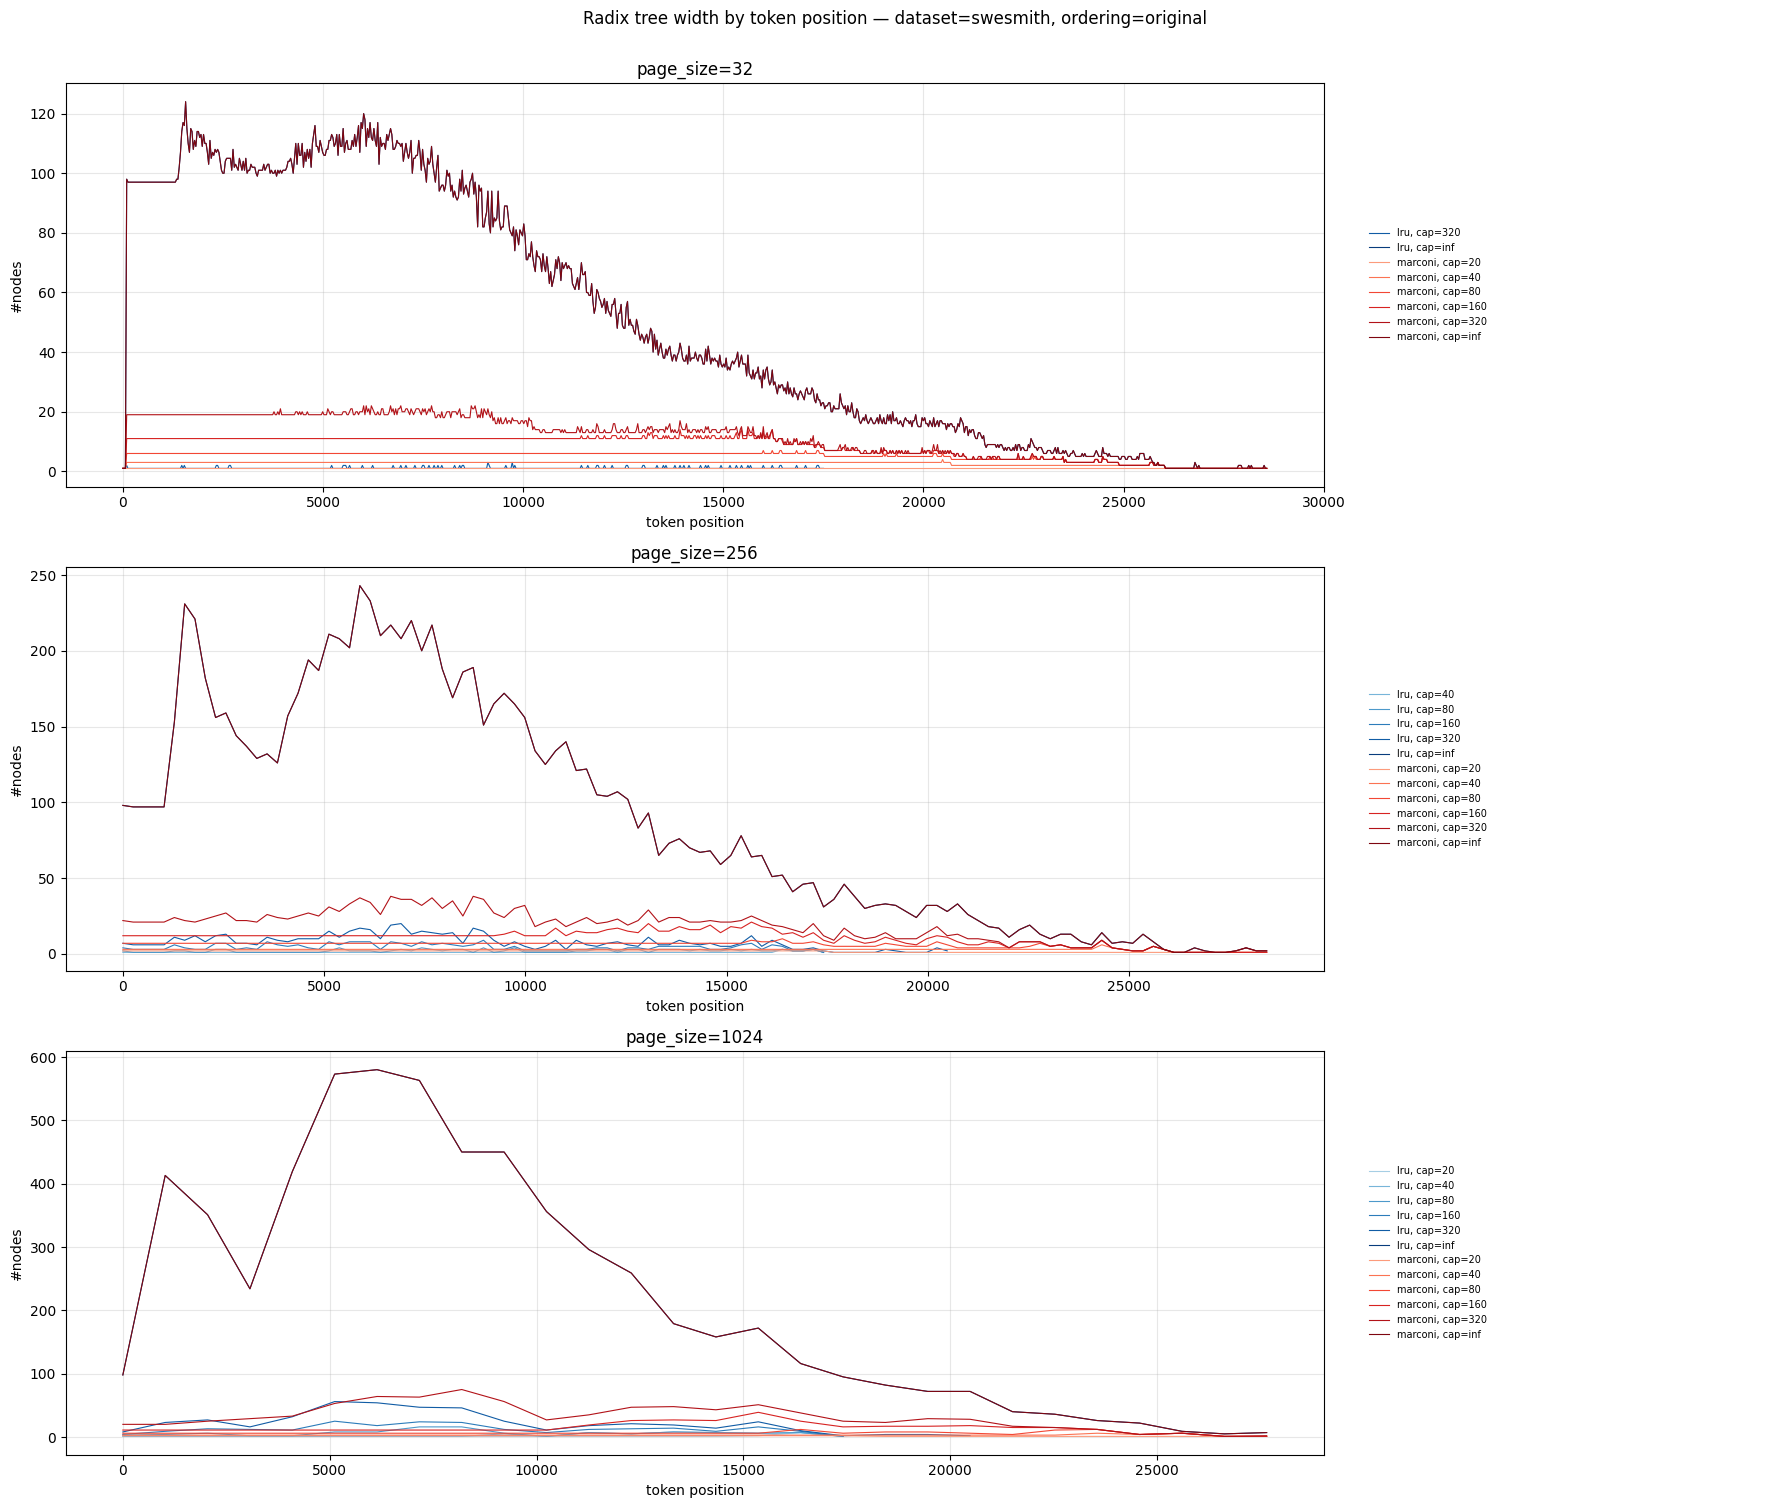

In [4]:
rows = load_result_jsons(JSON_SUBDIR)
# Filter by ordering
rows = [r for r in rows if r.get("ordering") == ORDERING]
print(f"Loaded {len(rows)} runs (ordering={ORDERING})")

if rows:
    strategies = sorted({r.get("strategy", "?") for r in rows})
    page_sizes = sorted({int(r.get("page_size", -1)) for r in rows})
    caps = sorted({r.get("capacity_spec", "?") for r in rows}, key=lambda c: float("inf") if c == "inf" else float(c))

    # Visual encoding: each strategy gets its own sequential colormap
    _strat_cmaps_names = ["Blues", "Reds", "Greens", "Purples", "Oranges"]
    strat_cmaps = {s: plt.get_cmap(_strat_cmaps_names[i % len(_strat_cmaps_names)])
                   for i, s in enumerate(strategies)}
    cap_positions = {c: v for c, v in zip(caps, np.linspace(0.35, 0.95, len(caps)))}

    def strat_cap_color(st: str, cap: str):
        return strat_cmaps[st](cap_positions[cap])

    # Index rows by (strategy, page_size, capacity_spec)
    lookup: dict[tuple, dict] = {}
    for row in rows:
        key = (row.get("strategy"), int(row.get("page_size", -1)), row.get("capacity_spec"))
        lookup[key] = row

    n_ps = len(page_sizes)
    fig, axes = plt.subplots(n_ps, 2, figsize=(18, 5 * n_ps), squeeze=False,
                             gridspec_kw={"width_ratios": [3, 1]})
    for ri, ps in enumerate(page_sizes):
        ax = axes[ri][0]
        ax_legend = axes[ri][1]
        ax_legend.axis("off")
        for st in strategies:
            for cap in caps:
                row = lookup.get((st, ps, cap))
                if not row:
                    continue
                h = (row.get("metrics") or {}).get("tree_depth_histogram") or {}
                if not h:
                    continue
                ser = depth_hist_to_series(h)
                token_pos = ser.index * ps
                ax.plot(token_pos, ser.values, "-",
                        lw=0.8, color=strat_cap_color(st, cap),
                        label=f"{st}, cap={cap}")
        ax.set_title(f"page_size={ps}")
        ax.set_ylabel("#nodes")
        ax.set_xlabel("token position")
        ax.grid(True, alpha=0.3)
        handles, labels = ax.get_legend_handles_labels()
        ax_legend.legend(handles, labels, fontsize=7, loc="center left", frameon=False)

    fig.suptitle(f"Radix tree width by token position — dataset={DATASET}, ordering={ORDERING}", y=1.002)
    plt.tight_layout()
    plt.show()

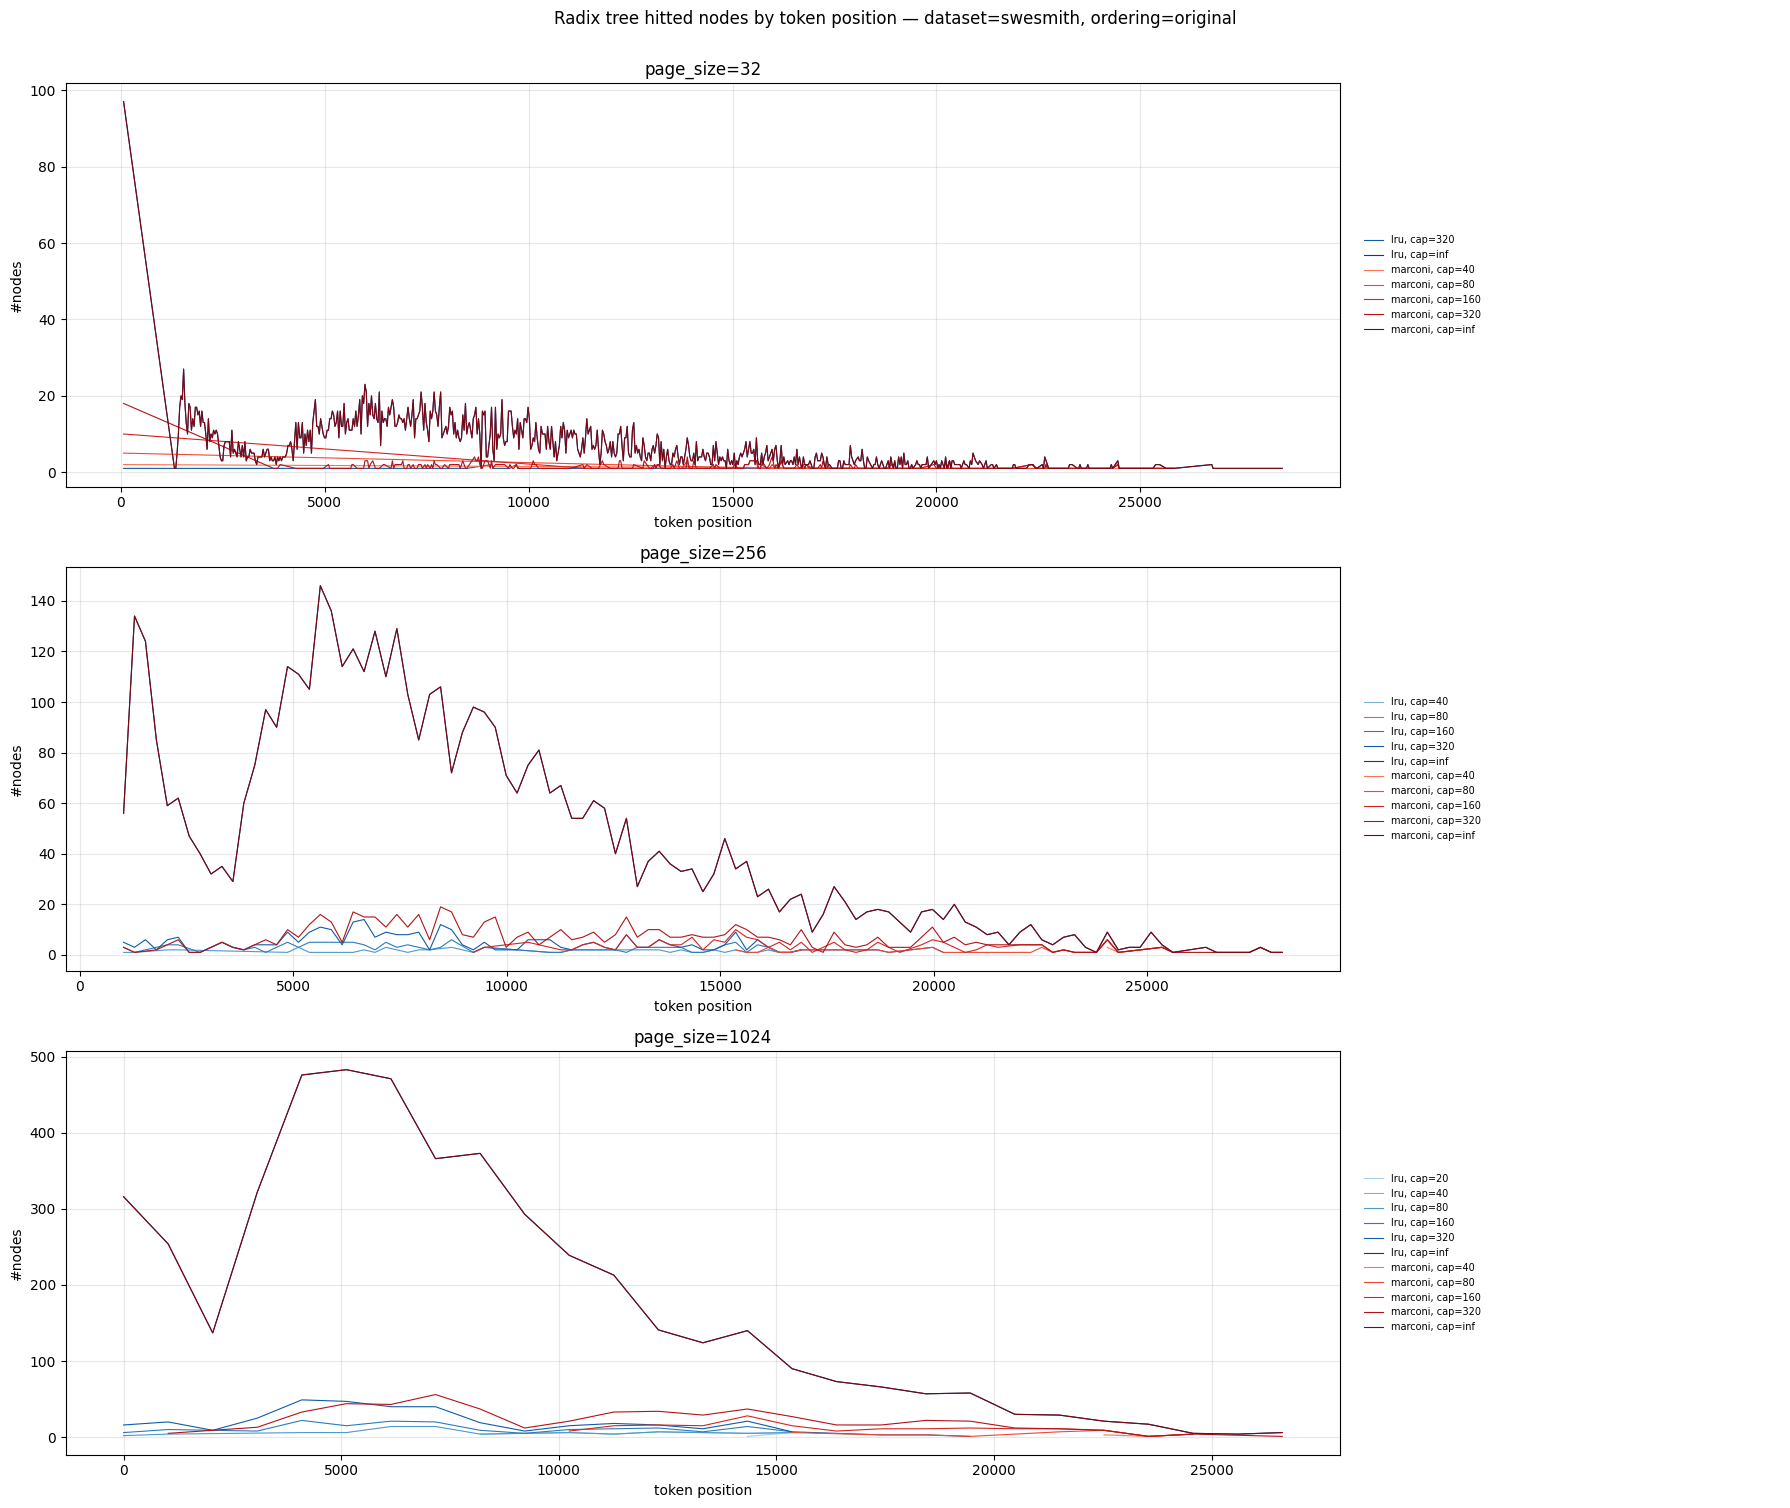

In [5]:
if rows:
    fig, axes = plt.subplots(n_ps, 2, figsize=(18, 5 * n_ps), squeeze=False,
                             gridspec_kw={"width_ratios": [3, 1]})
    for ri, ps in enumerate(page_sizes):
        ax = axes[ri][0]
        ax_legend = axes[ri][1]
        ax_legend.axis("off")
        for st in strategies:
            for cap in caps:
                row = lookup.get((st, ps, cap))
                if not row:
                    continue
                h = (row.get("metrics") or {}).get("valid_cached_depth_histogram") or {}
                if not h:
                    continue
                ser = depth_hist_to_series(h)
                token_pos = ser.index * ps
                ax.plot(token_pos, ser.values, "-",
                        lw=0.8, color=strat_cap_color(st, cap),
                        label=f"{st}, cap={cap}")
        ax.set_title(f"page_size={ps}")
        ax.set_ylabel("#nodes")
        ax.set_xlabel("token position")
        ax.grid(True, alpha=0.3)
        handles, labels = ax.get_legend_handles_labels()
        ax_legend.legend(handles, labels, fontsize=7, loc="center left", frameon=False)

    fig.suptitle(f"Radix tree hitted nodes by token position — dataset={DATASET}, ordering={ORDERING}", y=1.002)
    plt.tight_layout()
    plt.show()

## 2. Mean access count by token position

One row per `page_size`. Color family = strategy, shade = capacity.

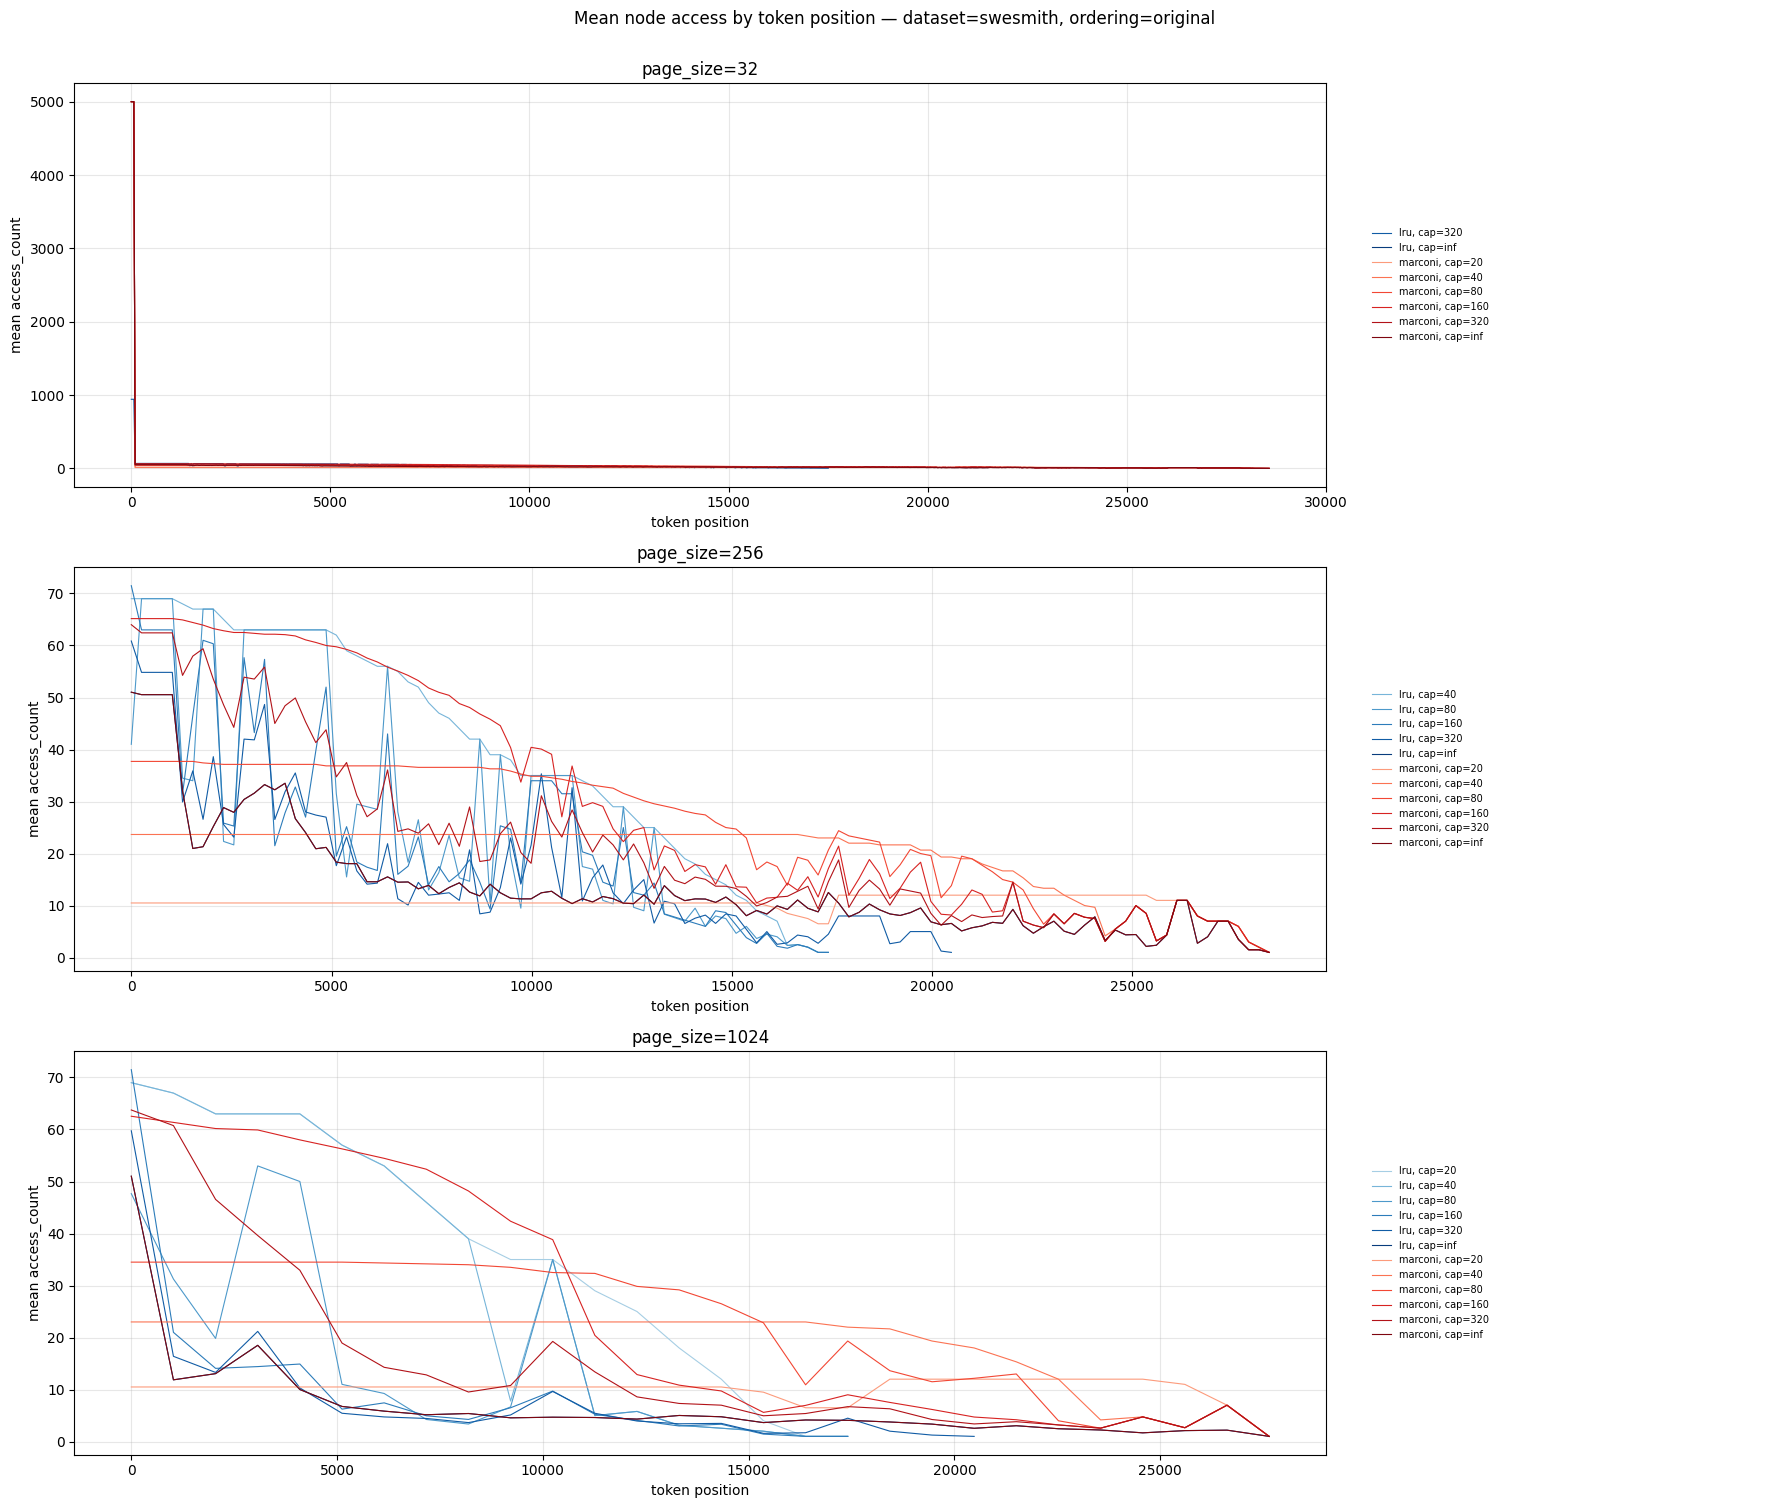

In [6]:
if rows:
    fig, axes = plt.subplots(n_ps, 2, figsize=(18, 5 * n_ps), squeeze=False,
                             gridspec_kw={"width_ratios": [3, 1]})
    for ri, ps in enumerate(page_sizes):
        ax = axes[ri][0]
        ax_legend = axes[ri][1]
        ax_legend.axis("off")
        for st in strategies:
            for cap in caps:
                row = lookup.get((st, ps, cap))
                if not row:
                    continue
                acc = (row.get("metrics") or {}).get("tree_access_by_depth") or {}
                if not acc:
                    continue
                df = access_agg_to_frame(acc)
                if df.empty:
                    continue
                token_pos = df["depth"] * ps
                ax.plot(token_pos, df["mean_access"], "-",
                        lw=0.8, color=strat_cap_color(st, cap),
                        label=f"{st}, cap={cap}")
        ax.set_title(f"page_size={ps}")
        ax.set_ylabel("mean access_count")
        ax.set_xlabel("token position")
        ax.grid(True, alpha=0.3)
        handles, labels = ax.get_legend_handles_labels()
        ax_legend.legend(handles, labels, fontsize=7, loc="center left", frameon=False)

    fig.suptitle(f"Mean node access by token position — dataset={DATASET}, ordering={ORDERING}", y=1.002)
    plt.tight_layout()
    plt.show()

## 3. Access-count band (p50–p90) by token position

One row per `page_size`. Color family = strategy, shade = capacity.

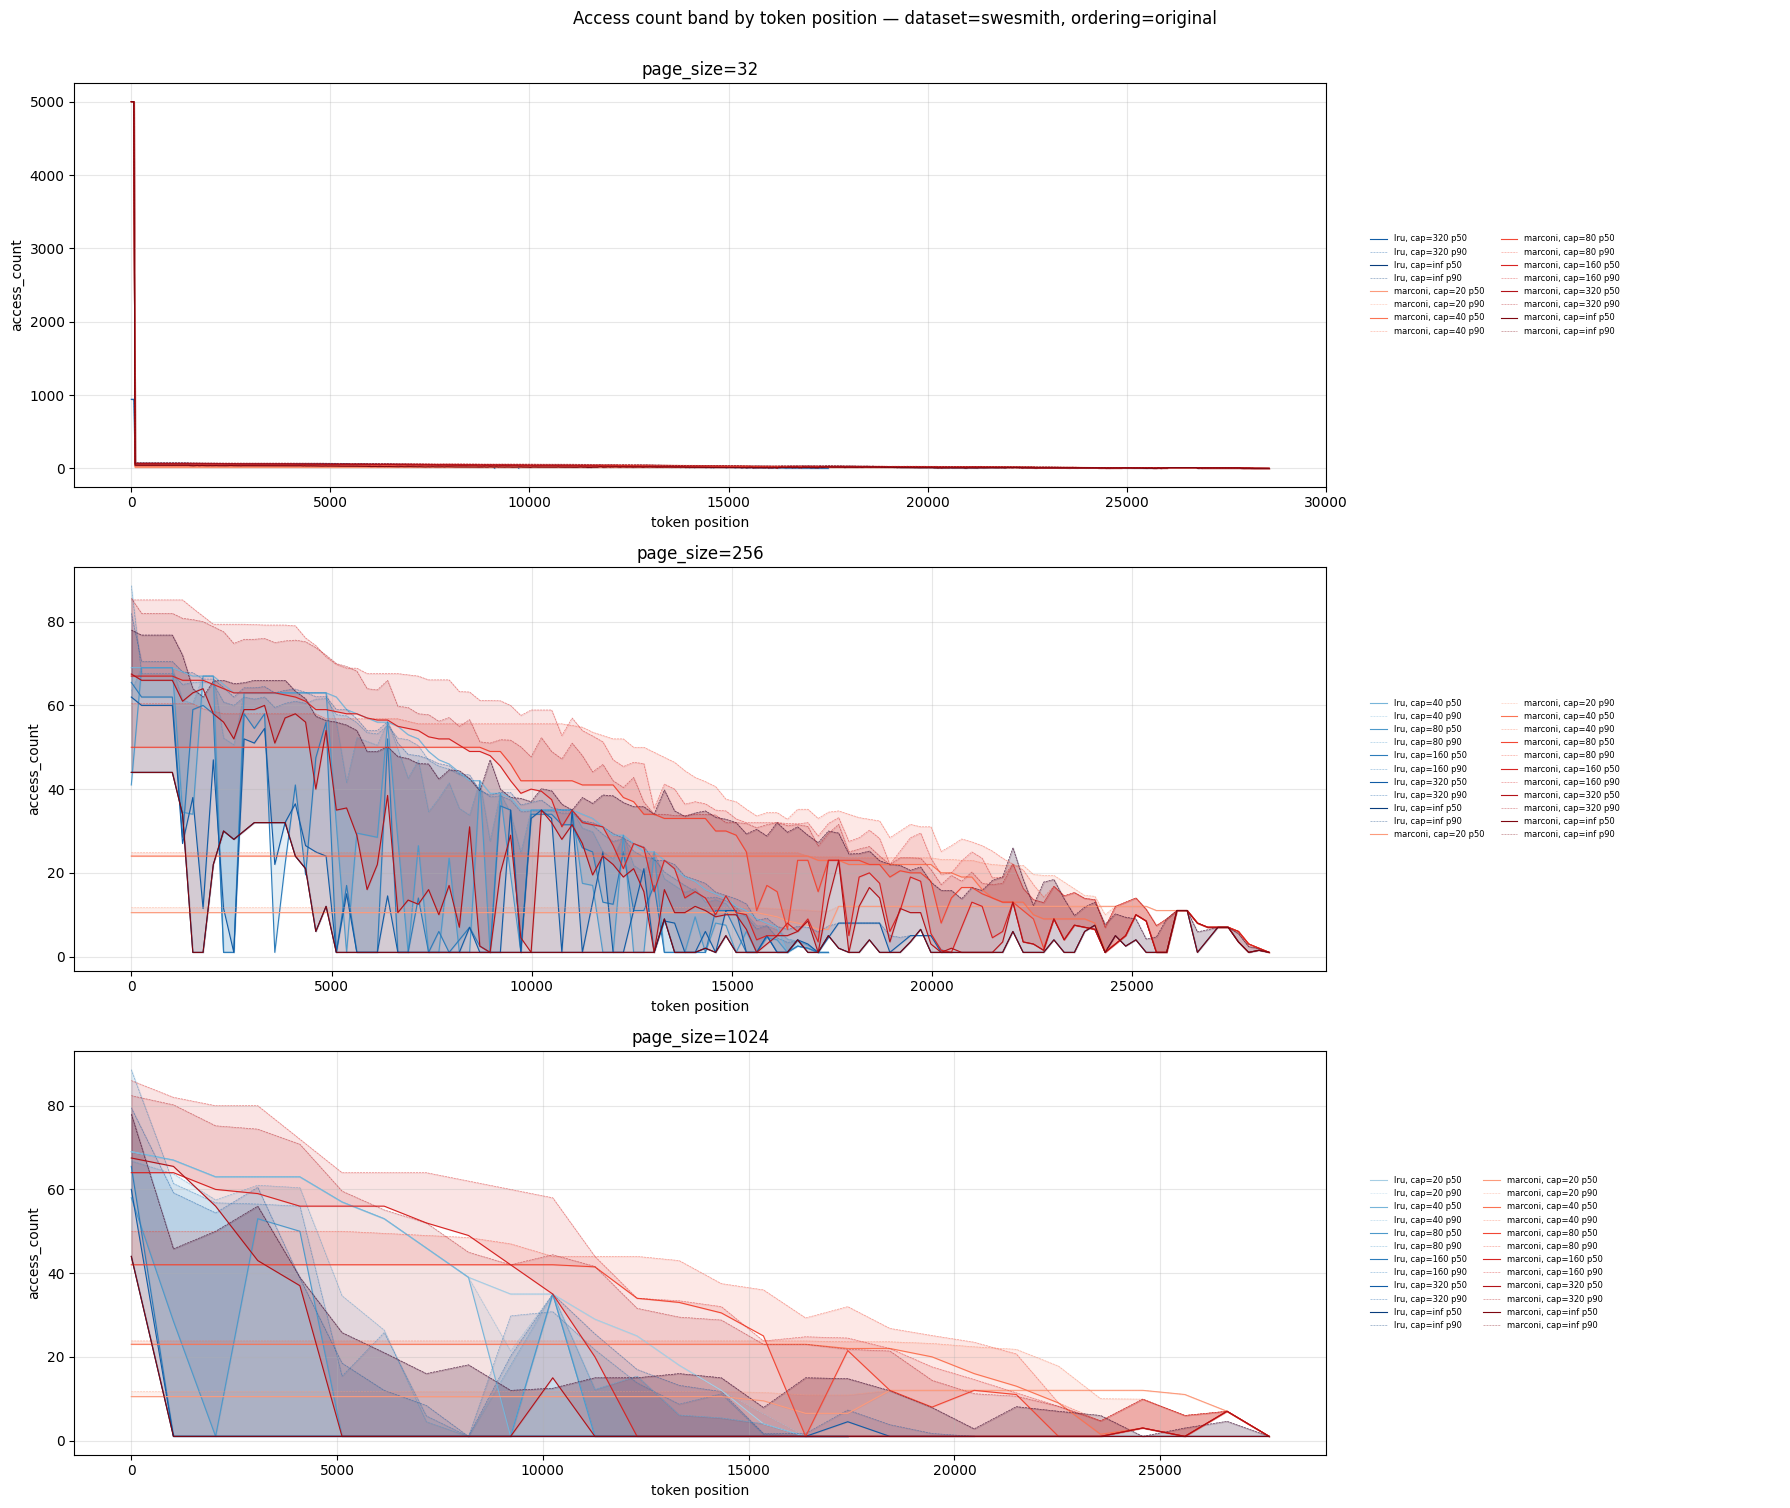

In [7]:
if rows:
    fig, axes = plt.subplots(n_ps, 2, figsize=(18, 5 * n_ps), squeeze=False,
                             gridspec_kw={"width_ratios": [3, 1]})
    for ri, ps in enumerate(page_sizes):
        ax = axes[ri][0]
        ax_legend = axes[ri][1]
        ax_legend.axis("off")
        for st in strategies:
            for cap in caps:
                row = lookup.get((st, ps, cap))
                if not row:
                    continue
                pct = (row.get("metrics") or {}).get("access_percentiles_by_depth") or {}
                if not pct:
                    continue
                df = percentiles_to_frame(pct)
                if df.empty:
                    continue
                token_pos = df["depth"] * ps
                c = strat_cap_color(st, cap)
                lbl = f"{st}, cap={cap}"
                ax.fill_between(token_pos, df["p50"], df["p90"],
                                alpha=0.12, color=c)
                ax.plot(token_pos, df["p50"], "-",
                        lw=0.8, color=c, label=f"{lbl} p50")
                ax.plot(token_pos, df["p90"], "--",
                        lw=0.4, alpha=0.6, color=c, label=f"{lbl} p90")
        ax.set_title(f"page_size={ps}")
        ax.set_ylabel("access_count")
        ax.set_xlabel("token position")
        ax.grid(True, alpha=0.3)
        handles, labels = ax.get_legend_handles_labels()
        ax_legend.legend(handles, labels, fontsize=6, loc="center left", frameon=False, ncol=2)

    fig.suptitle(f"Access count band by token position — dataset={DATASET}, ordering={ORDERING}", y=1.002)
    plt.tight_layout()
    plt.show()